# Mini-ResNet (5 Layers, 5 Epochs) — CIFAR-10 Classification
This notebook builds a small Residual Network (ResNet) using PyTorch, trains it on the CIFAR-10 dataset, and saves model weights.

---

### 1️⃣ Import Libraries and Setup Device
```python
import torch                       # Core PyTorch library
import torch.nn as nn              # Neural network modules
import torch.optim as optim        # Optimizers like Adam, SGD
import torch.nn.functional as F    # Activation functions (ReLU, etc.)
from torchvision import datasets, transforms   # Datasets & transforms
from torch.utils.data import DataLoader        # Data batching
import matplotlib.pyplot as plt    # For plotting training loss

# Detect GPU if available
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


## 2️⃣  Import Libraries and Setup Device:

# Convert images to tensors and normalize pixel values to range (–1, 1)
``` python
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
```

# Download CIFAR-10 training and test sets
``` python
train_dataset = datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)
test_dataset  = datasets.CIFAR10(root="./data", train=False, transform=transform, download=True)
```
# Create DataLoaders for batching (64 images per batch)
```python
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)
```

> Explanation:

> * Each CIFAR-10 image = 32×32 RGB (3 channels).

> * Normalization improves convergence.

> * shuffle=True ensures batches are mixed randomly each epoch.

# 3️⃣ Define the Residual Block

```Python
class ResidualBlock(nn.Module):
    """ Defines F(x) + x structure used in ResNets """
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        # First 3×3 convolution → changes spatial size if stride=2
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        # Second 3×3 convolution → keeps size same
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        # Optional downsample layer to match dimensions for skip path
        self.downsample = downsample

    def forward(self, x):
        identity = x                    # Save original input for skip connection
        out = F.relu(self.bn1(self.conv1(x)))  # Conv → BN → ReLU
        out = self.bn2(self.conv2(out))        # Conv → BN (no activation yet)
        if self.downsample:             # If shape mismatch, align identity path
            identity = self.downsample(x)
        out += identity                 # Add skip connection
        return F.relu(out)              # Final ReLU
```
> Explanation:
> * Each residual block learns a residual mapping 𝐹(𝑥).
> * Output = 𝐹(𝑥)+𝑥, helping gradients flow easily through deep networks.

# 4️⃣ Define the Mini-ResNet Model
``` python
class MiniResNet(nn.Module):
    """A small ResNet with ~5 convolutional layers total"""
    def __init__(self, num_classes=10):
        super().__init__()
        # Initial 3×3 convolution: RGB → 16 channels
        self.layer1 = nn.Conv2d(3, 16, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        # Residual Block 1: keeps 16 channels
        self.resblock1 = ResidualBlock(16, 16)

        # Residual Block 2: doubles channels 16→32 and downsamples spatially
        self.resblock2 = ResidualBlock(16, 32, stride=2, downsample=nn.Sequential(
            nn.Conv2d(16, 32, 1, 2, bias=False),   # 1×1 conv for alignment
            nn.BatchNorm2d(32)
        ))

        # Global average pooling + fully connected output
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(32, num_classes)
  ```

 ``` python
    def forward(self, x):
        x = F.relu(self.bn1(self.layer1(x)))  # Initial conv
        x = self.resblock1(x)                 # First residual block
        x = self.resblock2(x)                 # Second residual block
        x = self.avgpool(x)                   # Reduce H×W to 1×1
        x = torch.flatten(x, 1)               # Flatten for linear layer
        return self.fc(x)                     # Class logits
```
> Explanation:

> * Total 5 convolutional layers (1 + 2 per block).

> * Ends with pooling and fully connected classifier.

# 5️⃣ Initialize Model, Loss, and Optimizer

```python
model = MiniResNet().to(DEVICE)       # Send model to GPU if available
criterion = nn.CrossEntropyLoss()     # Standard loss for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer

EPOCHS = 5                            # Number of full dataset passes
losses = []                           # Track loss for plotting
```

# 6️⃣ Training Loop

```python
for epoch in range(EPOCHS):
    model.train()                     # Enable training mode (BatchNorm active)
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()         # Clear previous gradients
        outputs = model(images)       # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()               # Backpropagation
        optimizer.step()              # Update weights

        running_loss += loss.item()   # Accumulate loss

    epoch_loss = running_loss / len(train_loader)
    losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss:.4f}")
```
> Explanation:

> * Each epoch processes every batch once.
> * .backward() computes gradients, .step() updates weights.
> * Prints average loss per epoch.

7️⃣ Save Trained Weights

```python
torch.save(model.state_dict(), "mini_resnet_weights.pth")  # Save parameters
print("✅ Weights saved as mini_resnet_weights.pth")
```

To reload later
``` python
model.load_state_dict(torch.load("mini_resnet_weights.pth"))
model.eval()
```


# 8️⃣ Evaluate on Test Data
``` python
model.eval()                          # Inference mode
correct, total = 0, 0
with torch.no_grad():                 # No gradient tracking for evaluation
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        preds = model(x).argmax(1)    # Get class with max probability
        correct += (preds == y).sum().item()
        total += y.size(0)
print(f"🎯 Test Accuracy: {100*correct/total:.2f}%")
```


# 9️⃣ Plot Training Loss
``` python
plt.plot(range(1, EPOCHS+1), losses, marker="o")
plt.title("Training Loss Curve — Mini-ResNet")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True); plt.show()
```
> Interpretation:
> * Loss should generally decrease each epoch — if it rises, check learning rate or data normalization.

# How to Modify the Model


| Goal                        | Change                                                                   | Example                |
| --------------------------- | ------------------------------------------------------------------------ | ---------------------- |
| More epochs               | Change `EPOCHS = 5` → `EPOCHS = 20`                                      | Trains longer          |
| Add more residual blocks | Duplicate `self.resblock2` pattern with 32→64 channels                   | Deeper ResNet          |
| Change optimizer         | Replace Adam with `optim.SGD(model.parameters(), lr=0.01, momentum=0.9)` | Classic ResNet style   |
| Save full model          | `torch.save(model, "model_full.pth")`                                    | Includes architecture  |
| Different dataset        | Replace CIFAR-10 loader                                                  | e.g., `datasets.MNIST` |


# ResNet Code Example with Cifar 10 Classification.

 Device: cuda
Epoch 1/5 | Loss: 1.5865
Epoch 2/5 | Loss: 1.2597
Epoch 3/5 | Loss: 1.1419
Epoch 4/5 | Loss: 1.0665
Epoch 5/5 | Loss: 1.0159
Saved as mini_resnet_weights.pth
Accuracy: 64.50%


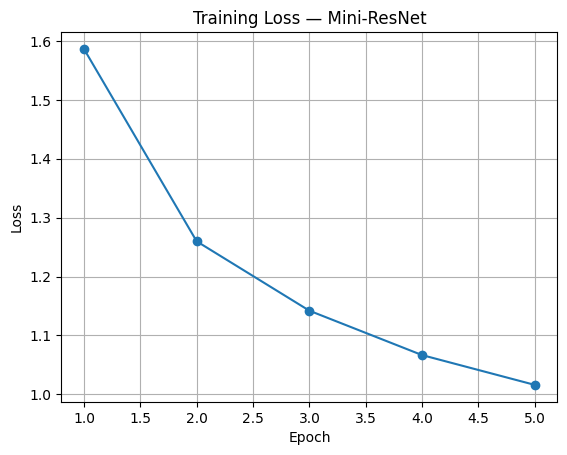

In [41]:
# ==================================================================
# Mini-ResNet (5 layers, 5 epochs) — CIFAR-10 Classification Example
# ==================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1️⃣ Device CPU or GPU
# ------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(" Device:", DEVICE)

# ------------------------------------------------------------
# 2️⃣ Datasets from Pytorch
# ------------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)
test_dataset  = datasets.CIFAR10(root="./data", train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ------------------------------------------------------------
# 3️⃣ Residual Block / Identity Block => F(x) = x
# ------------------------------------------------------------
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample:
            identity = self.downsample(x)
        out += identity
        return F.relu(out)

# ------------------------------------------------------------
# 4️⃣ Mini-ResNet Model
# ------------------------------------------------------------
class MiniResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.layer1 = nn.Conv2d(3, 16, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.resblock1 = ResidualBlock(16, 16)
        self.resblock2 = ResidualBlock(16, 32, stride=2, downsample=nn.Sequential(
            nn.Conv2d(16, 32, 1, 2, bias=False),
            nn.BatchNorm2d(32)
        ))
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.layer1(x)))
        x = self.resblock1(x)
        x = self.resblock2(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

# ------------------------------------------------------------
# 5️⃣ Training the model for 5 epochs
# ------------------------------------------------------------
model = MiniResNet().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 5
losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss:.4f}")

# ------------------------------------------------------------
# 6️⃣ Save weights in a .pth file to use later.
# ------------------------------------------------------------
torch.save(model.state_dict(), "mini_resnet_weights.pth")
print("Saved as mini_resnet_weights.pth")

# ------------------------------------------------------------
# 7️⃣ Evaluate the model
# ------------------------------------------------------------
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        preds = model(x).argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)
print(f"Accuracy: {100*correct/total:.2f}%")

# ------------------------------------------------------------
# 8️⃣ Plot loss curve
# ------------------------------------------------------------
plt.plot(range(1, EPOCHS+1), losses, marker="o")
plt.title("Training Loss — Mini-ResNet")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True); plt.show()
